# Data Exploration

## I. Tổng quan về dữ liệu thô

### 1. Tải thư viện & đọc file

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno


In [3]:
path = "../data/amazon_crawl/amazon_products_US_20260324_231228.csv"
try:
    df = pd.read_csv(path)
    print("[SUCCESS]: Loading dataset successful")
except Exception as e:
    print(f"[ERROR]: Loading dataset fail: {e}")

[SUCCESS]: Loading dataset successful


### 2. Thông tin cơ bản

In [4]:
df.head()

,asin,title,price,original_price,rating,reviews,currency,is_best_seller,is_amazon_choice,is_prime,...,video_thumbnail,has_video,key_features,full_description,technical_details,product_details,has_aplus_content,aplus_images,has_brand_story,frequently_bought_together
0,B08NHSPCR6,HP Chromebook 11A G8 Education Edition AMD A4-...,NaN,NaN,4.1,1161,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,B0GR6F8HXV,Apple 2026 MacBook Neo 13-inch Laptop with A18...,749.00,NaN,4.8,73,USD,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,B0D7NVS6RV,"Lenovo Yoga 7i 2-in-1 Laptop, 16&quot; 2K Touc...",799.99,NaN,4.5,167,USD,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,B08H5878D3,LEXiBOOK Spider-Man - Educational and Bilingua...,49.99,NaN,4.2,1355,USD,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,B0791H74NT,Creative Pebble 2.0 USB-Powered Desktop Speake...,23.74,24.99,4.5,67192,USD,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### 2.1. Kích thước dữ liệu

In [5]:
print(f"Data shape: {df.shape}")

num_rows, num_columns = df.shape
print(f"Amount of rows is: {num_rows}")
print(f"Amount of columns is: {num_columns}")

Data shape: (9180, 58)
Amount of rows is: 9180
Amount of columns is: 58


#### 2.2. Kiểu dữ liệu và ý nghĩa của các đặc trưng

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9180 entries, 0 to 9179
Data columns (total 58 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   asin                        9180 non-null   object 
 1   title                       9180 non-null   object 
 2   price                       8910 non-null   float64
 3   original_price              4096 non-null   float64
 4   rating                      9157 non-null   float64
 5   reviews                     9180 non-null   int64  
 6   currency                    8939 non-null   object 
 7   is_best_seller              9180 non-null   bool   
 8   is_amazon_choice            9180 non-null   bool   
 9   is_prime                    9180 non-null   bool   
 10  sales_volume                8308 non-null   object 
 11  main_category               9180 non-null   object 
 12  category_hierarchy          9180 non-null   object 
 13  crawl_category              9180 

| STT | Feature | Đơn vị | Ý nghĩa |
|-----|--------|-------|--------|
| 1 | asin | Không có | Mã định danh duy nhất của sản phẩm trên Amazon (ASIN). |
| 2 | title | Không có | Tiêu đề sản phẩm hiển thị trên Amazon, chứa thông tin mô tả chính. |
| 3 | price | USD ($) | Giá hiện tại của sản phẩm tại thời điểm crawl. |
| 4 | original_price | USD ($) | Giá gốc trước khi giảm giá (nếu có). |
| 5 | rating | Điểm (0–5) | Điểm đánh giá trung bình từ người dùng. |
| 6 | reviews | Số lượng | Tổng số lượt đánh giá (reviews) của sản phẩm. |
| 7 | currency | Không có | Đơn vị tiền tệ (ví dụ: USD). |
| 8 | is_best_seller | Boolean | Sản phẩm có thuộc danh sách Best Seller hay không. |
| 9 | is_amazon_choice | Boolean | Sản phẩm có được gắn nhãn “Amazon’s Choice” hay không. |
| 10 | is_prime | Boolean | Sản phẩm có hỗ trợ Amazon Prime hay không. |
| 11 | sales_volume | Không có | Số lượng bán ra (thường dạng text như “500+ bought”). |
| 12 | main_category | Không có | Danh mục chính của sản phẩm (ví dụ: electronics). |
| 13 | category_hierarchy | Không có | Cấu trúc phân cấp danh mục (dạng list hoặc JSON). |
| 14 | crawl_category | Không có | Danh mục dùng khi crawl dữ liệu. |
| 15 | link | URL | Đường dẫn đến trang sản phẩm. |
| 16 | image_url | URL | Đường dẫn đến ảnh chính của sản phẩm. |
| 17 | delivery_info | Không có | Thông tin giao hàng (thời gian, phí, khu vực). |
| 18 | number_of_offers | Số lượng | Số người bán cung cấp sản phẩm. |
| 19 | lowest_offer_price | USD ($) | Giá thấp nhất trong các offer. |
| 20 | has_variations | Boolean | Sản phẩm có nhiều biến thể hay không. |
| 21 | is_climate_friendly | Boolean | Sản phẩm có thân thiện môi trường hay không. |
| 22 | variation_dimensions | Không có | Các chiều biến thể (màu, size, cấu hình...). |
| 23 | variants | Không có | Thông tin các biến thể hiện tại. |
| 24 | all_variants | Không có | Danh sách toàn bộ biến thể của sản phẩm. |
| 25 | top_reviews | Không có | Các đánh giá nổi bật của sản phẩm. |
| 26 | detailed_rating | Không có | Phân bố rating chi tiết (5 sao, 4 sao...). |
| 27 | current_price | USD ($) | Giá hiện tại (có thể trùng với price). |
| 28 | product_name | Không có | Tên rút gọn của sản phẩm. |
| 29 | slug | Không có | Chuỗi định danh URL thân thiện (SEO). |
| 30 | parent_asin | Không có | ASIN của sản phẩm cha (nếu là biến thể). |
| 31 | landing_asin | Không có | ASIN trang landing chính. |
| 32 | brand_info | Không có | Thông tin thương hiệu. |
| 33 | brand_url | URL | Đường dẫn tới trang thương hiệu. |
| 34 | brand_urls | URL | Danh sách các URL liên quan đến brand. |
| 35 | unit_price | USD ($) | Giá trên mỗi đơn vị sản phẩm. |
| 36 | unit_count | Số lượng | Số lượng đơn vị trong sản phẩm. |
| 37 | min_order_quantity | Số lượng | Số lượng tối thiểu cần mua (hiện tại null). |
| 38 | country | Không có | Quốc gia bán hoặc phân phối sản phẩm. |
| 39 | availability | Không có | Tình trạng còn hàng. |
| 40 | condition | Không có | Tình trạng sản phẩm (new, used...). |
| 41 | estimated_delivery_date | Ngày | Ngày giao hàng dự kiến. |
| 42 | customer_feedback_summary | Không có | Tổng hợp phản hồi khách hàng (hiện null). |
| 43 | top_reviews_global | Không có | Review nổi bật toàn cầu. |
| 44 | is_bestseller | Không có | Cờ bestseller (phiên bản khác của is_best_seller). |
| 45 | main_image_url | URL | URL ảnh chính chi tiết. |
| 46 | additional_image_urls | URL | Danh sách ảnh bổ sung. |
| 47 | product_videos | Không có | Video chính thức của sản phẩm. |
| 48 | user_videos | Không có | Video do người dùng đăng. |
| 49 | video_thumbnail | URL | Ảnh thumbnail của video. |
| 50 | has_video | Boolean | Sản phẩm có video hay không. |
| 51 | key_features | Không có | Các đặc điểm nổi bật (bullet points). |
| 52 | full_description | Không có | Mô tả chi tiết sản phẩm. |
| 53 | technical_details | Không có | Thông số kỹ thuật chi tiết. |
| 54 | product_details | Không có | Thông tin chi tiết bổ sung. |
| 55 | has_aplus_content | Boolean | Có nội dung A+ (Enhanced Brand Content). |
| 56 | aplus_images | URL | Hình ảnh trong nội dung A+. |
| 57 | has_brand_story | Boolean | Có câu chuyện thương hiệu hay không. |
| 58 | frequently_bought_together | Không có | Danh sách sản phẩm thường mua cùng. |

### 3. Kiểm tra dòng trùng lặp

In [7]:
duplicated_rows = df.duplicated().sum()
print(f"Number of duplicated rows: {duplicated_rows}")

Number of duplicated rows: 382


Có 382 dòng trùng lặp, sẽ tiến hành xóa các dòng trùng lặp này.

In [8]:
df = df.drop_duplicates()

In [9]:
print(f"Data shape after removing duplicates: {df.shape}")

Data shape after removing duplicates: (8798, 58)


### 4. Kiểm tra dữ liệu thiếu

Khi quan sát dữ liệu ban đầu, có thể thấy nhiều cột xuất hiện các giá trị như [], {} hoặc chuỗi rỗng. Điều này có thể làm sai lệch kết quả khi phân tích. Vì vậy, trước tiên cần chuyển các giá trị này về dạng NaN để thống nhất cách biểu diễn dữ liệu thiếu. Sau khi thực hiện bước này, tiến hành kiểm tra tỷ lệ missing của từng feature để hiểu rõ mức độ thiếu dữ liệu.

In [ ]:
df = df.replace(["[]", "{}", ""], np.nan)
zero_missing_cols = 0
list_missing_values = []

for col in df.columns:
    missing_count = df[col].isnull().sum()
    missing_percentage = (missing_count / df.shape[0]) * 100
    list_missing_values.append({
        "Feature": col,
        "Missing": missing_count,
        "Percentage": f"{missing_percentage:.2f}%"
    })
    if missing_percentage > 85:
        zero_missing_cols += 1

df_missing_values = pd.DataFrame(list_missing_values)
df_missing_values = df_missing_values.sort_values(by="Missing", ascending=False)
print(df_missing_values)

print(f"Number of columns with more than 85% missing values: {zero_missing_cols}")

                       Feature  Missing Percentage
36          min_order_quantity     8798    100.00%
41   customer_feedback_summary     8798    100.00%
47                 user_videos     8798    100.00%
34                  unit_price     8535     97.01%
35                  unit_count     8535     97.01%
39                   condition     8509     96.72%
57  frequently_bought_together     8402     95.50%
51            full_description     8316     94.52%
46              product_videos     7953     90.40%
22                    variants     7914     89.95%
48             video_thumbnail     7910     89.91%
42          top_reviews_global     7882     89.59%
40     estimated_delivery_date     7834     89.04%
50                key_features     7832     89.02%
28                        slug     7822     88.91%
23                all_variants     7817     88.85%
21        variation_dimensions     7816     88.84%
29                 parent_asin     7816     88.84%
38                availability 

In [17]:
def plot_missing_values(df):
    import matplotlib.pyplot as plt
    import seaborn as sns

    plt.figure(figsize=(14, 10))
    sns.set_theme(style="whitegrid")

    # Convert % string → float nếu cần
    if df["Percentage"].dtype == object:
        df["Percentage"] = df["Percentage"].str.replace("%", "").astype(float)

    # Sort giảm dần cho dễ nhìn
    df = df.sort_values(by="Percentage", ascending=False)

    # Plot
    ax = sns.barplot(
        x="Percentage",
        y="Feature",
        data=df,
        palette="Reds_r",
        hue="Feature"
    )

    # Title & label
    plt.title("Tỷ lệ Khuyết thiếu Dữ liệu theo Đặc trưng",
              fontsize=16, fontweight="bold", pad=20)
    plt.xlabel("Tỷ lệ khuyết thiếu (%)", fontsize=12, fontweight="bold")
    plt.ylabel("Tên đặc trưng", fontsize=12, fontweight="bold")

    # Hiển thị value trên thanh
    for p in ax.patches:
        width = p.get_width()
        ax.text(width + 1, p.get_y() + p.get_height()/2,
                f"{width:.2f}%",
                va="center", fontsize=10, fontweight="bold")

    # Scale hợp lý
    plt.xlim(0, 100)

    plt.tight_layout()
    plt.show()

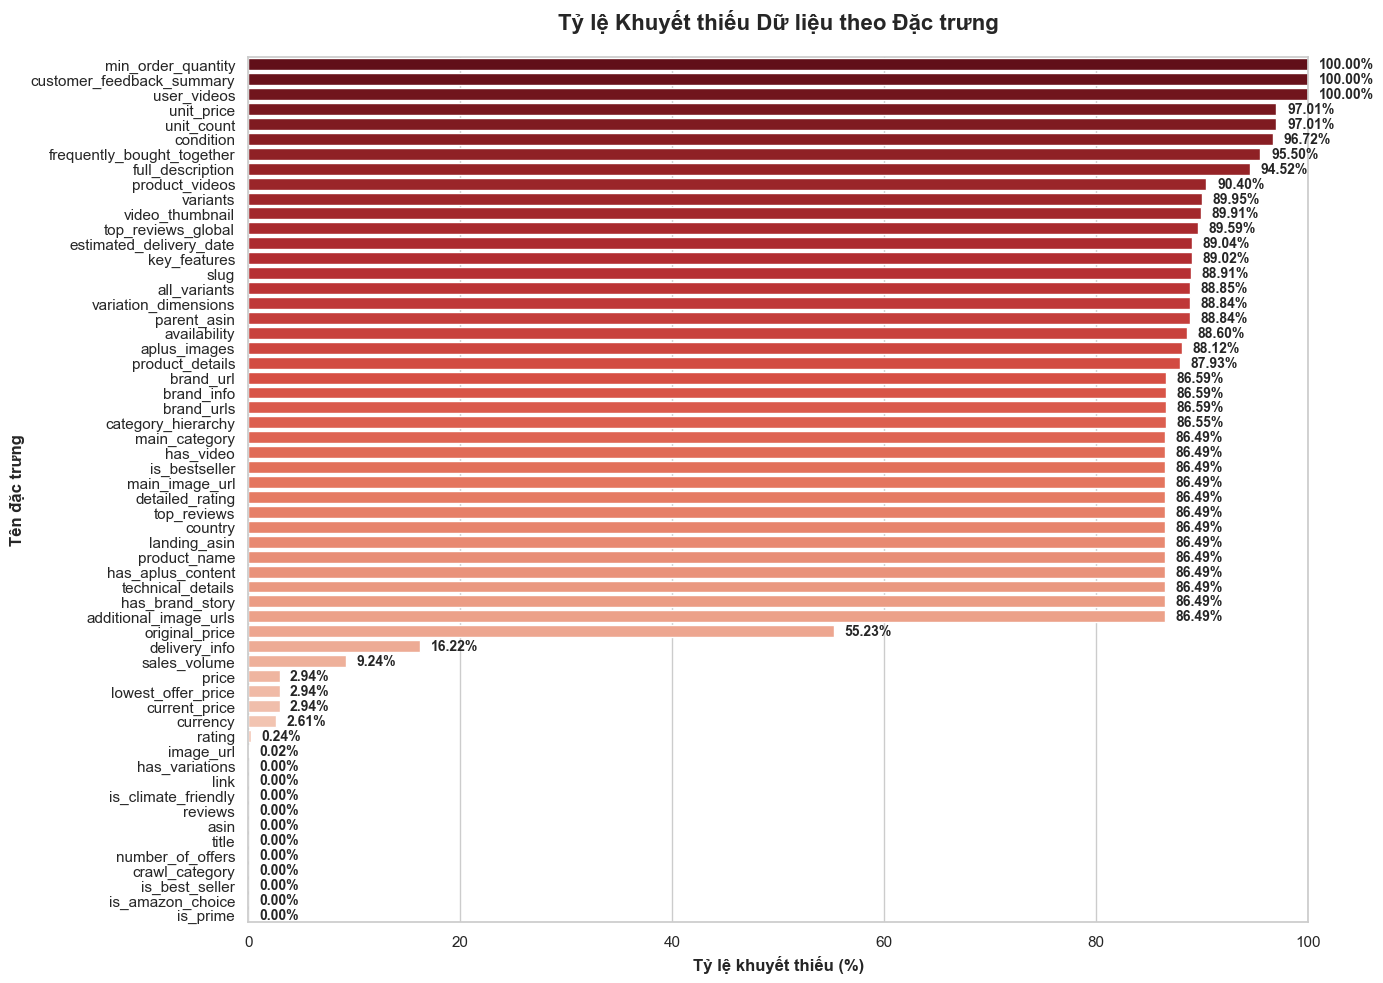

In [18]:
plot_missing_values(df_missing_values)

Dựa trên kết quả đã phân tích, có tới 38 feature có tỷ lệ missing vượt quá 85%. Với mức độ thiếu dữ liệu quá lớn như vậy, các feature này không còn mang nhiều ý nghĩa trong việc phân tích hay xây dựng mô hình. Do đó, trong bước tiền xử lý dữ liệu, ta sẽ tiến hành loại bỏ các cột này nhằm giảm nhiễu và cải thiện chất lượng dữ liệu đầu vào.

In [19]:
cols_to_drop = []

for col in df.columns:
    missing_percentage = (df[col].isnull().sum() / len(df)) * 100
    
    if missing_percentage > 85:
        cols_to_drop.append(col)

df = df.drop(columns=cols_to_drop)

print(f"Dropped {len(cols_to_drop)} columns with missing values > 85%")

Dropped 38 columns with missing values > 85%


**Kiểm tra lại tỉ lệ missing**

In [20]:
list_missing_values = []

for col in df.columns:
    missing_count = df[col].isnull().sum()
    missing_percentage = (missing_count / df.shape[0]) * 100
    list_missing_values.append({
        "Feature": col,
        "Missing": missing_count,
        "Percentage": f"{missing_percentage:.2f}%"
    })

df_missing_values = pd.DataFrame(list_missing_values)
df_missing_values = df_missing_values.sort_values(by="Missing", ascending=False)
print(df_missing_values)

                Feature  Missing Percentage
3        original_price     4859     55.23%
14        delivery_info     1427     16.22%
10         sales_volume      813      9.24%
2                 price      259      2.94%
16   lowest_offer_price      259      2.94%
19        current_price      259      2.94%
6              currency      230      2.61%
4                rating       21      0.24%
13            image_url        2      0.02%
1                 title        0      0.00%
0                  asin        0      0.00%
5               reviews        0      0.00%
11       crawl_category        0      0.00%
9              is_prime        0      0.00%
8      is_amazon_choice        0      0.00%
7        is_best_seller        0      0.00%
15     number_of_offers        0      0.00%
12                 link        0      0.00%
17       has_variations        0      0.00%
18  is_climate_friendly        0      0.00%


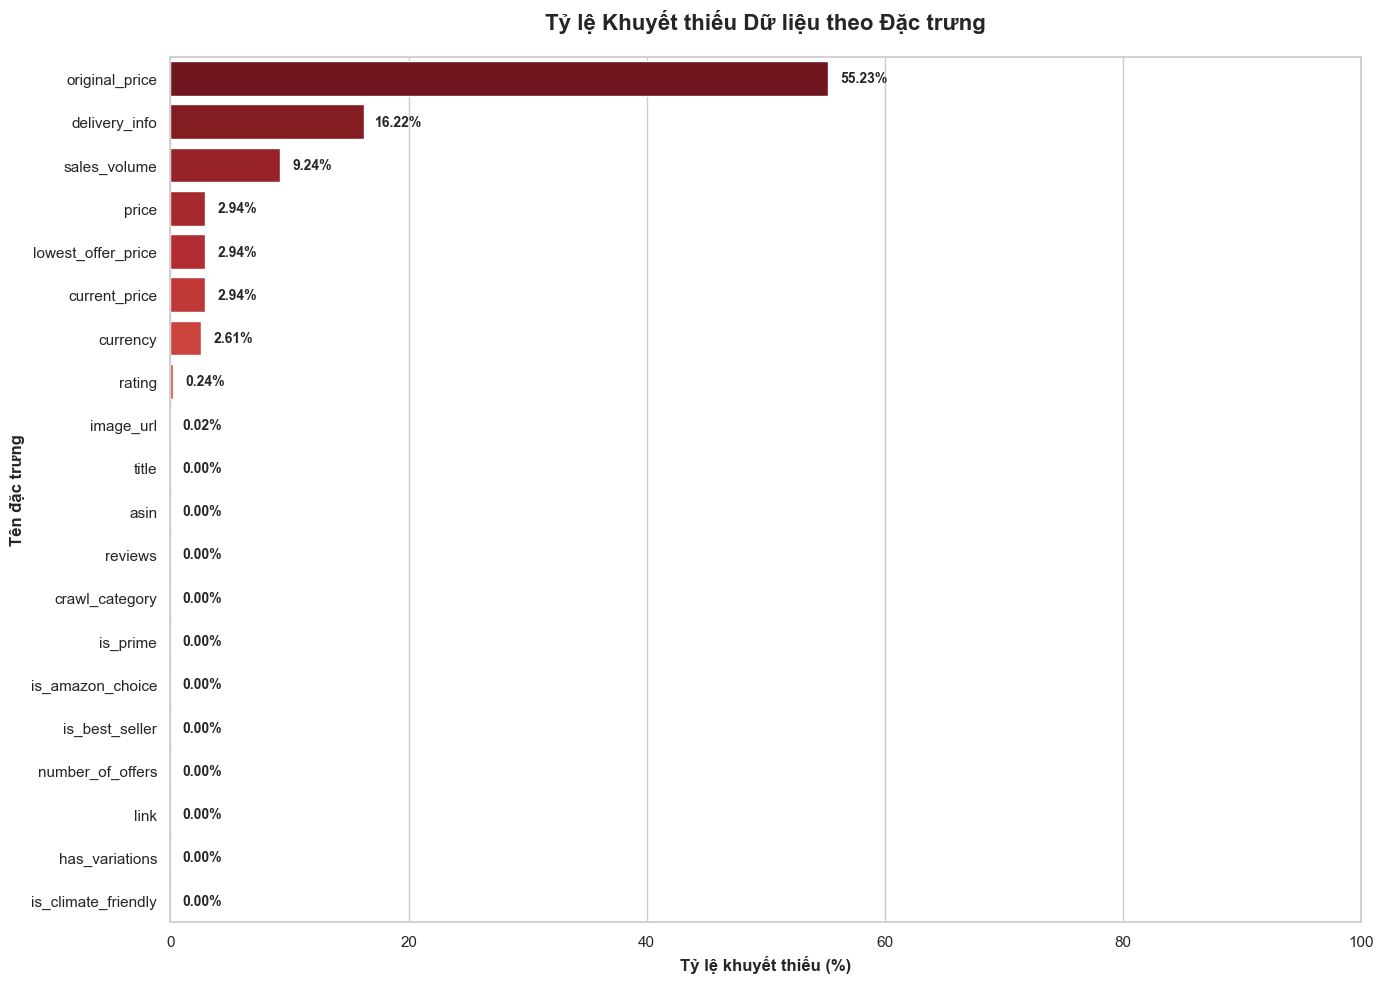

In [21]:
plot_missing_values(df_missing_values)

## II. Phân Tích Khám Phá

### 1. Phân tích các đặc trưng Numerical

#### 1.1 Trích xuất đặc trưng

In [22]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"There are {len(numeric_cols)} numeric columns.")
print(numeric_cols)

There are 7 numeric columns.
['price', 'original_price', 'rating', 'reviews', 'number_of_offers', 'lowest_offer_price', 'current_price']


#### 1.2. Giá trị phân phối


In [23]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
price,8539.0,76.260172,162.102657,0.00,13.99,26.95,69.99,3399.99
original_price,3939.0,84.933379,155.987674,2.85,19.99,34.99,89.99,2499.99
rating,8777.0,4.448752,0.296391,1.00,4.30,4.50,4.60,5.00
reviews,8798.0,9686.216526,22813.652361,0.00,420.25,2206.50,8696.50,659066.00
number_of_offers,8798.0,2.205729,3.868529,1.00,1.00,1.00,2.00,80.00
lowest_offer_price,8539.0,71.335759,151.524271,0.62,13.99,25.98,67.82,3399.99
current_price,8539.0,76.259403,162.102491,0.00,13.99,26.95,69.99,3399.99


**Nhận xét phân phối theo từng đặc trưng**

##### 1. price
- Mean ≈ 76.26, median (50%) ≈ 26.95 → **lệch phải mạnh**
- Q1 ≈ 13.99, Q3 ≈ 69.99 → khoảng giá phổ biến thấp
- Max = 3399.99 >> Q3 → **có nhiều outlier lớn**
- Min = 0 → có thể là dữ liệu lỗi hoặc sản phẩm miễn phí

**Kết luận:** Phân phối lệch phải, nhiều outliers → nên log transform hoặc xử lý outlier



##### 2. original_price
- Mean ≈ 84.93 > median ≈ 34.99 → **lệch phải**
- Max = 2499.99 → có outlier
- Missing nhiều (count thấp)

**Kết luận:** Dữ liệu không đầy đủ, phân phối tương tự price → cân nhắc fill hoặc drop


##### 3. rating
- Mean ≈ 4.45, median ≈ 4.5 → **phân phối khá cân đối**
- Min = 1, max = 5 → đúng range
- Std ≈ 0.29 → **ít biến động**

**Kết luận:** Dữ liệu ổn định, phù hợp làm feature cho model


##### 4. reviews
- Mean ≈ 9686, median ≈ 420 → **lệch phải cực mạnh**
- Q3 ≈ 2206 nhưng max = 659066 → **outlier rất lớn**
- Min = 0 → có sản phẩm chưa có review

**Kết luận:** Phân phối rất skewed → nên dùng log(reviews + 1)

##### 5. number_of_offers
- Mean ≈ 2.2, median = 1 → **đa số chỉ có 1 seller**
- Q3 = 1 → phân phối lệch phải nhẹ
- Max = 80 → có outlier

**Kết luận:** Feature có thể hữu ích nhưng nên xử lý outlier


##### 6. lowest_offer_price
- Mean ≈ 71.33, median ≈ 25.98 → **lệch phải**
- Max = 3399.99 → có outlier
- Phân phối gần giống price

**Kết luận:** Có thể trùng thông tin với price → nên kiểm tra tương quan


##### 7. current_price
- Gần giống hoàn toàn price (mean, median, max tương tự)
- Có thể là bản duplicate của price

**Kết luận:** Nên kiểm tra và có thể **drop 1 trong 2 cột (price hoặc current_price)**


##### Tổng kết chung
- Hầu hết các biến giá và số lượng đều **lệch phải (right-skewed)**
- Nhiều feature có **outliers rất lớn**
- Một số feature bị **trùng thông tin (price vs current_price)**
- rating là feature **ổn định nhất**

##### **Đề xuất tiền xử lý:**
- Log transform: `price`, `reviews`, `lowest_offer_price`
- Drop: `current_price` (nếu trùng với price)
- Xử lý outliers: clipping hoặc IQR
- Xử lý missing: đặc biệt với `original_price`

In [24]:
palette = sns.color_palette("Set2", len(numeric_cols))
sns.set_style("whitegrid")

def plot_numerical_distribution_and_boxplot(col, i):
    color = palette[i]
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Histogram
    sns.histplot(
        data=df,
        x=col,
        kde=True,
        bins=40,
        ax=axes[0],
        color=color,
        edgecolor="white"
    )
    axes[0].set_title(f'Distribution of {col}', fontsize=13, weight='bold')
    axes[0].set_xlabel(col)

    # Boxplot
    sns.boxplot(
        data=df,
        x=col,
        ax=axes[1],
        color=color,
        width=0.4
    )
    axes[1].set_title(f'Box Plot of {col}', fontsize=13, weight='bold')
    axes[1].set_xlabel(col)

    plt.tight_layout()
    plt.show()

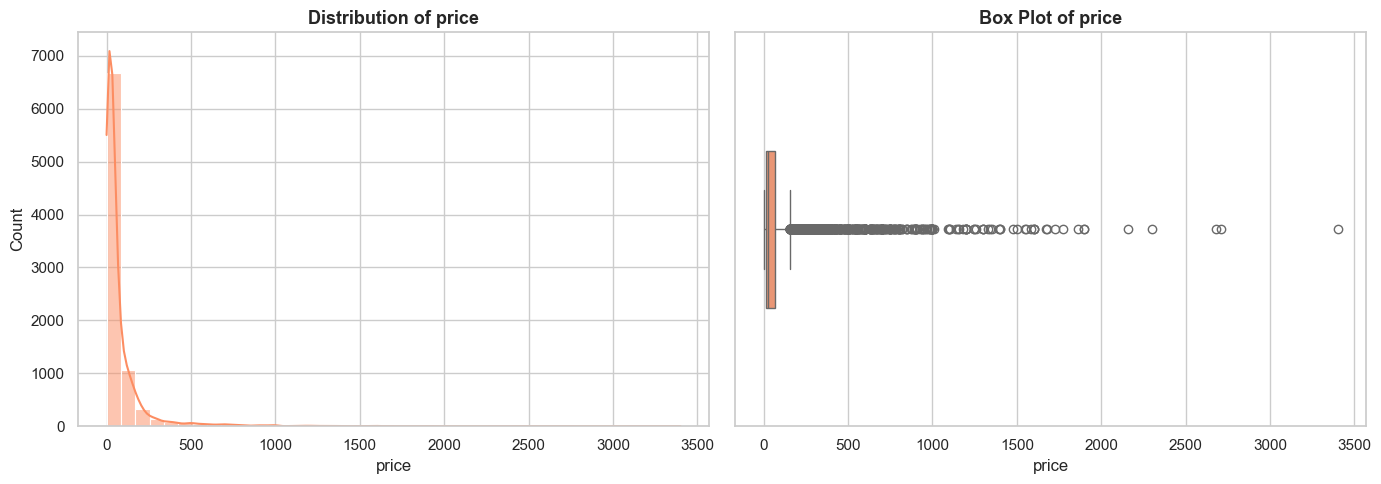

In [25]:
plot_numerical_distribution_and_boxplot(numeric_cols[0], 1)

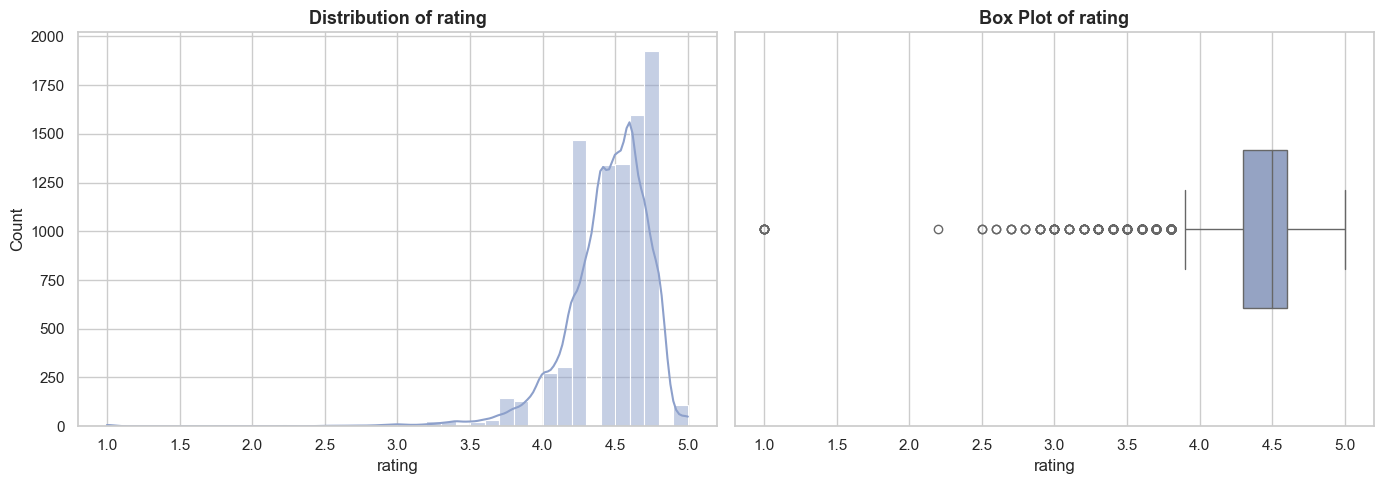

In [27]:
plot_numerical_distribution_and_boxplot(numeric_cols[2], 2)

### 2. Phân tích các đặc trưng Categorical

#### 2.1. Trích xuất đặc trưng

In [28]:
categorical_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()
print(f"There are {len(categorical_cols)} categorical columns.")
print(categorical_cols)

There are 8 categorical columns.
['asin', 'title', 'currency', 'sales_volume', 'crawl_category', 'link', 'image_url', 'delivery_info']


#### 2.2. Giá trị phân phối

In [29]:
def plot_categorical_distribution(col_count, col_name, top_n=5):
    top_vals = col_count.nlargest(top_n).index
    top_counts = col_count.nlargest(top_n).values

    plt.figure(figsize=(12, 5))
    sns.barplot(x=top_counts, y=top_vals, hue=top_vals, palette="viridis", legend=False)
    plt.title(f'Most Frequent {col_name}', fontsize=15)
    plt.xlabel('Number of Appearances', fontsize=12)
    plt.ylabel(col_name, fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

Cột `sales_volume`

There are 30 unique values in sales_volume column.
Most frequent sales_volume values is: 1K+ bought in past month with 872 appearances.


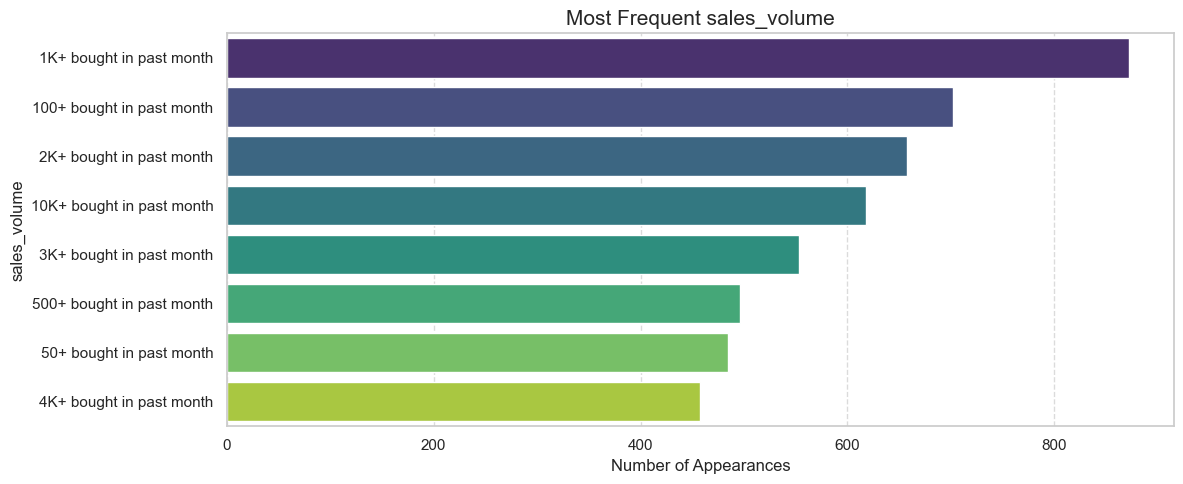

In [31]:

unique = df[categorical_cols[3]].nunique()
counts = df[categorical_cols[3]].value_counts()
print(f'There are {unique} unique values in {categorical_cols[3]} column.')
print(f'Most frequent {categorical_cols[3]} values is: {counts.idxmax()} with {counts.max()} appearances.')
plot_categorical_distribution(counts, categorical_cols[3], top_n = 8)

### 3. Phân tích các đặc trưng kiểu dữ liệu bool

#### 1. Trích xuất đặc trưng

In [32]:
bool_cols = df.select_dtypes(include=['bool', 'boolean']).columns.tolist()
print(f"There are {len(bool_cols)} boolean columns.")
print(bool_cols)

There are 5 boolean columns.
['is_best_seller', 'is_amazon_choice', 'is_prime', 'has_variations', 'is_climate_friendly']


In [33]:
df[bool_cols].describe()

,is_best_seller,is_amazon_choice,is_prime,has_variations,is_climate_friendly
count,8798,8798,8798,8798,8798
unique,1,2,2,2,2
top,True,False,False,False,False
freq,8798,8175,8725,7268,7264


**Nhận xét phân phối theo từng đặc trưng (Boolean)**

##### 1. is_best_seller
- unique = 1 → chỉ có 1 giá trị duy nhất
- Tất cả đều là True (100%)

**Kết luận:** Feature không có khả năng phân biệt → nên loại bỏ khỏi mô hình


##### 2. is_amazon_choice
- False chiếm ~93%, True ~7%
- Phân phối mất cân bằng nhưng vẫn có sự phân biệt

**Kết luận:** Là feature có ý nghĩa (Amazon’s Choice là tín hiệu mạnh) → nên giữ


##### 3. is_prime
- False chiếm ~99%, True ~1%
- Phân phối cực kỳ lệch

**Kết luận:** Có thể ít đóng góp cho mô hình → cân nhắc giữ hoặc loại tùy kết quả thực nghiệm


##### 4. has_variations
- False chiếm ~83%, True ~17%
- Có sự phân biệt tương đối giữa hai nhóm

**Kết luận:** Feature hữu ích, phản ánh mức độ đa dạng sản phẩm → nên giữ


##### 5. is_climate_friendly
- False chiếm ~83%, True ~17%
- Phân phối tương tự has_variations

**Kết luận:** Có thể liên quan đến xu hướng tiêu dùng → nên giữ


##### Tổng kết chung
- Một số feature bị **mất cân bằng mạnh (imbalanced)** như is_prime, is_amazon_choice
- Có feature **không có variance** như is_best_seller
- Một số feature vẫn mang ý nghĩa tốt cho mô hình

##### **Đề xuất tiền xử lý:**
- Drop: `is_best_seller`
- Encode Boolean → 0/1
- Kiểm tra lại hiệu quả của `is_prime` trong mô hình

## III. Quan hệ & Tương quan